<a href="https://colab.research.google.com/github/shivangi5678/Customer_churnanalysis/blob/main/Customerchurn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Telco_customer_churn.xlsx to Telco_customer_churn.xlsx


---First 5 Rows---


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices



--- Dataset Info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Int

/tmp/ipykernel_809/3432326661.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1, 1], x='Churn Label', y='Monthly Charges', data=df, palette=['#2b5c8f', '#d9534f'])


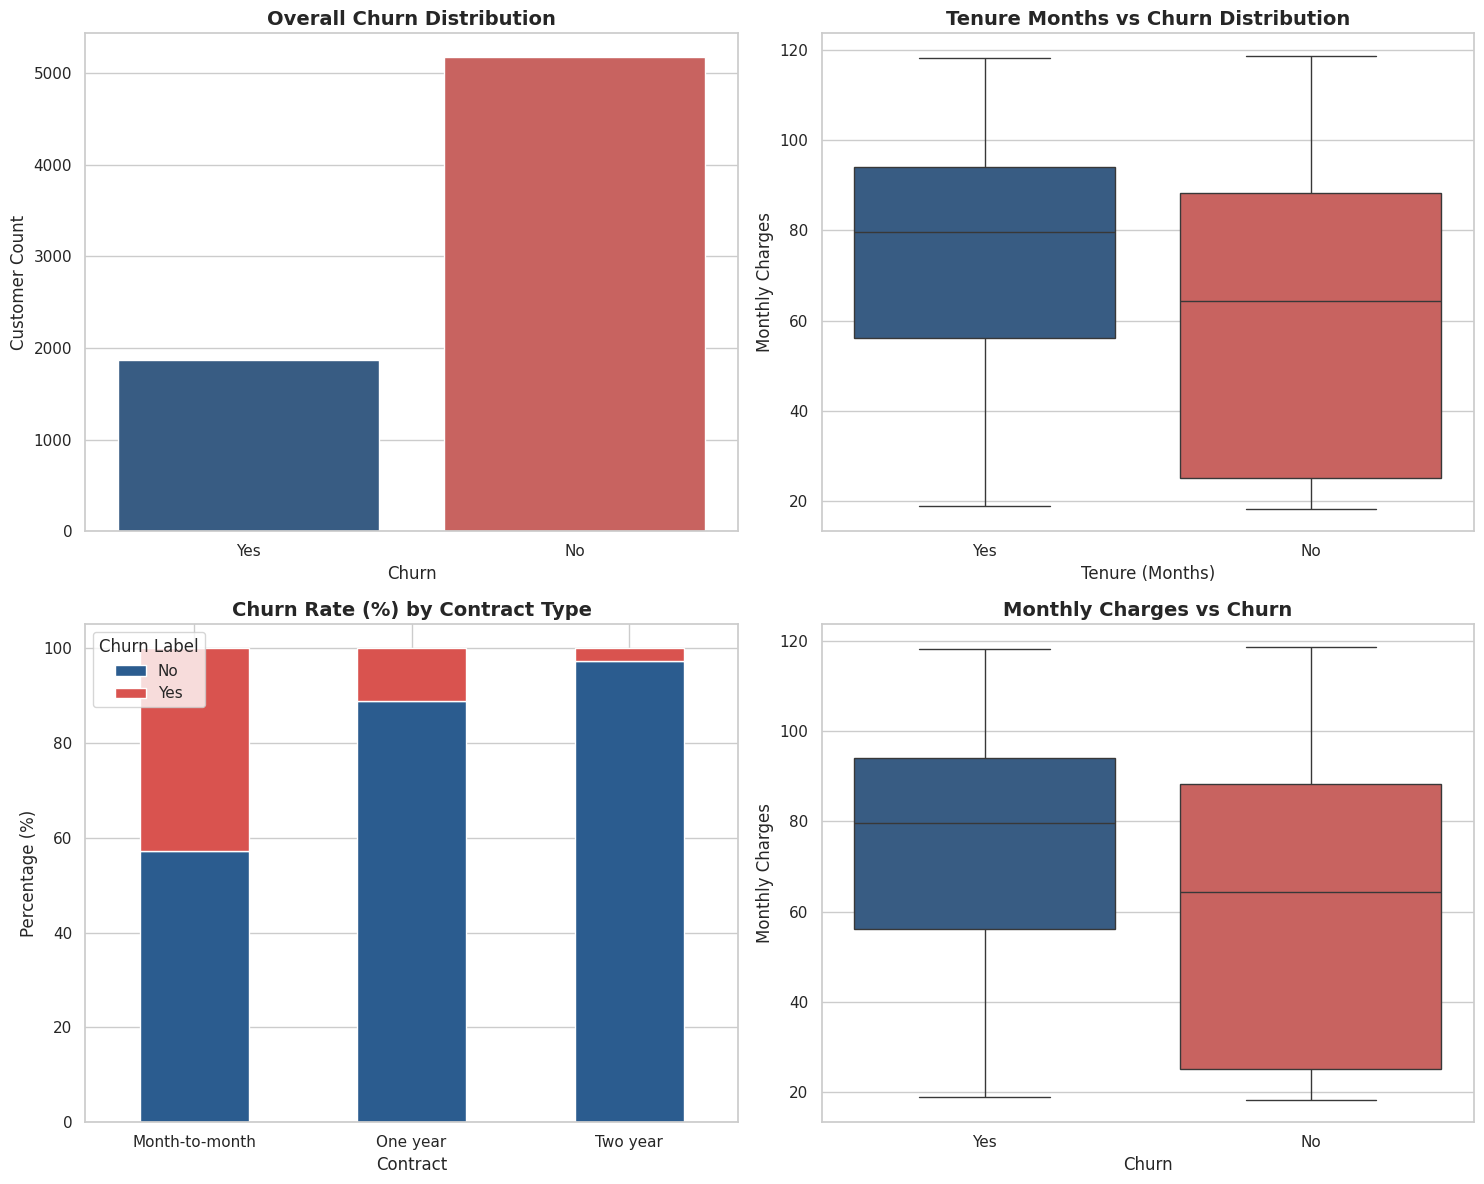

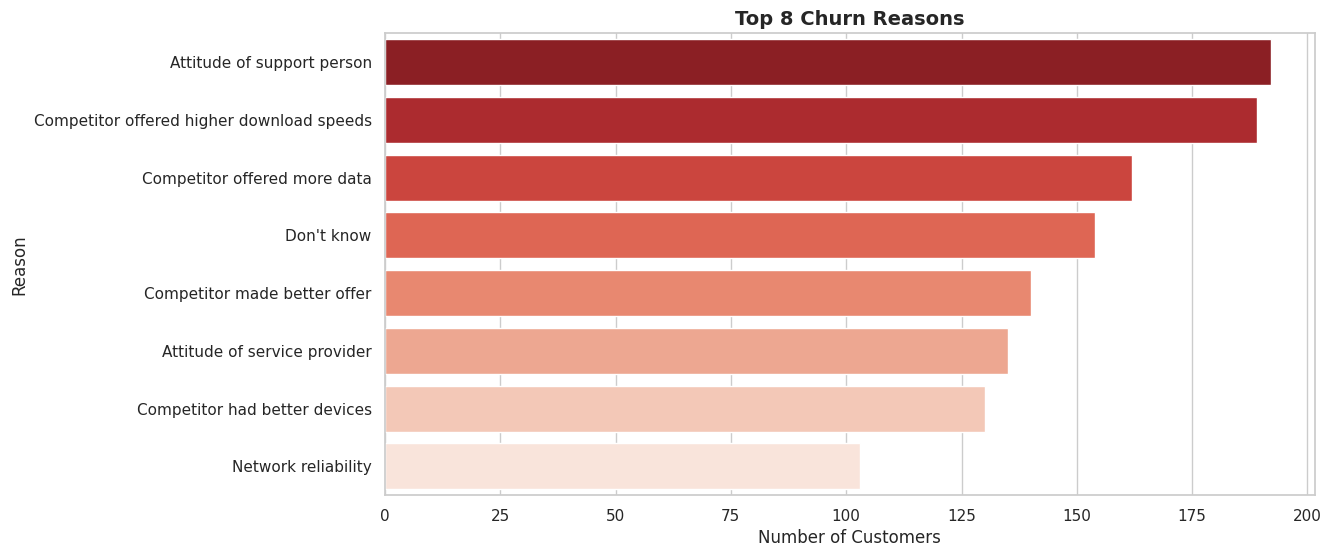

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel('Telco_customer_churn.xlsx')
print("---First 5 Rows---")
display(df.head())
print ("\n--- Dataset Info---")
df.info()
print("\n---Missing Value Count---")
print(df.isnull().sum())

#convert total charges in numeric
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors = 'coerce')

#check the total nan valur in charges
print("Missing in Total Charges:", df['Total Charges'].isnull().sum())

#fill the blank values with 0
df['Total Charges'] = df['Total Charges'].fillna(0)
print("Missing in Total Charges:", df['Total Charges'].isnull().sum())

#fill the missing value of churn reason with not churned
df['Churn Reason'] = df['Churn Reason'].fillna('Not Churned')

#check target column distribution
print("\n--- Target Distrinution (Count)---")
print(df['Churn Value'].value_counts())
print('\n---Churn rate(%)---')
print(df['Churn Value'].value_counts(normalize=True)*100)

#CHECK clean dataframe info
print("\n---Update Data types---")
print(df[['Tenure Months','Monthly Charges', 'Total Charges']].dtypes)

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Overall Churn Distribution
sns.countplot(ax=axes[0, 0], x='Churn Label', hue='Churn Label', data=df, palette=['#2b5c8f', '#d9534f'], legend=False)
axes[0, 0].set_title('Overall Churn Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Churn')
axes[0, 0].set_ylabel('Customer Count')

# 2. Tenure vs Churn
sns.boxplot(ax=axes[0, 1], x='Churn Label', y='Monthly Charges', hue='Churn Label', data=df, palette=['#2b5c8f', '#d9534f'], legend=False)
axes[0, 1].set_title('Tenure Months vs Churn Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Tenure (Months)')

# 3. Contract Type vs Churn
contract_churn = pd.crosstab(df['Contract'], df['Churn Label'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#2b5c8f', '#d9534f'], rot=0)
axes[1, 0].set_title('Churn Rate (%) by Contract Type', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Percentage (%)')

# 4. Monthly Charges Distribution by Churn
sns.boxplot(ax=axes[1, 1], x='Churn Label', y='Monthly Charges', data=df, palette=['#2b5c8f', '#d9534f'])
axes[1, 1].set_title('Monthly Charges vs Churn', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Churn')

plt.tight_layout()
plt.show()

# Top reasons why customers churned
churned_df = df[df['Churn Value'] == 1]

plt.figure(figsize=(12, 6))
top_reasons = churned_df['Churn Reason'].value_counts().head(8)
sns.barplot(x=top_reasons.values, y=top_reasons.index, hue=top_reasons.index, palette='Reds_r', legend=False)
plt.title('Top 8 Churn Reasons', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers')
plt.ylabel('Reason')
plt.show()



In [ ]:
# 1. Feature Engineering: Total Services count karna
services = ['Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security',
            'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']

# Calculate number of active services per customer
df['Total Services'] = (df[services] == 'Yes').sum(axis=1)

# Feature Engineering: Tenure Grouping
bins = [0, 12, 24, 48, 72]
labels = ['0-12m', '13-24m', '25-48m', '49-72m']
df['Tenure Group'] = pd.cut(df['Tenure Months'], bins=bins, labels=labels, right=True, include_lowest=True)

# 2. Select Features for ML (Dropping IDs, coordinates, and data leakage columns)
drop_cols = [
    'CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
    'Lat Long', 'Latitude', 'Longitude', 'Churn Label', 'Churn Score',
    'CLTV', 'Churn Reason'
]

ml_df = df.drop(columns=drop_cols)

# Separate Features (X) and Target (y)
X = ml_df.drop('Churn Value', axis=1)
y = ml_df['Churn Value']

# 3. One-Hot Encoding for categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

print("Original Features Shape:", X.shape)
print("Encoded Features Shape (after dummy encoding):", X_encoded.shape)
print("\nSample Encoded Columns:")
print(X_encoded.columns[:10].tolist())

# 4. Train-Test Split (80% Train, 20% Test with Stratification)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Scale numerical features
scaler = StandardScaler()
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Total Services']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("\n--- Split Summary ---")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Original Features Shape: (7043, 21)
Encoded Features Shape (after dummy encoding): (7043, 34)

Sample Encoded Columns:
['Tenure Months', 'Monthly Charges', 'Total Charges', 'Total Services', 'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'Phone Service_Yes', 'Multiple Lines_No phone service']

--- Split Summary ---
X_train shape: (5634, 34), y_train shape: (5634,)
X_test shape: (1409, 34), y_test shape: (1409,)


In [ ]:
# 1. Import ML models & metrics
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# 2. Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

# 3. Train, Predict and Evaluate each model
results = []

for name, model in models.items():
    # Model training
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred_proba)

    results.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision (%)": round(prec * 100, 2),
        "Recall (%)": round(rec * 100, 2),
        "F1-Score (%)": round(f1 * 100, 2),
        "ROC-AUC": round(roc, 4)
    })

# 4. Display Comparison Table
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print("--- Model Performance Comparison ---")
display(results_df)

--- Model Performance Comparison ---


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC
3,Gradient Boosting,80.20,65.37,54.01,59.15,0.8523
2,Random Forest,80.62,68.23,50.53,58.06,0.8521
0,Logistic Regression,79.99,64.47,54.81,59.25,0.8497
1,Decision Tree,79.84,63.31,57.22,60.11,0.8356


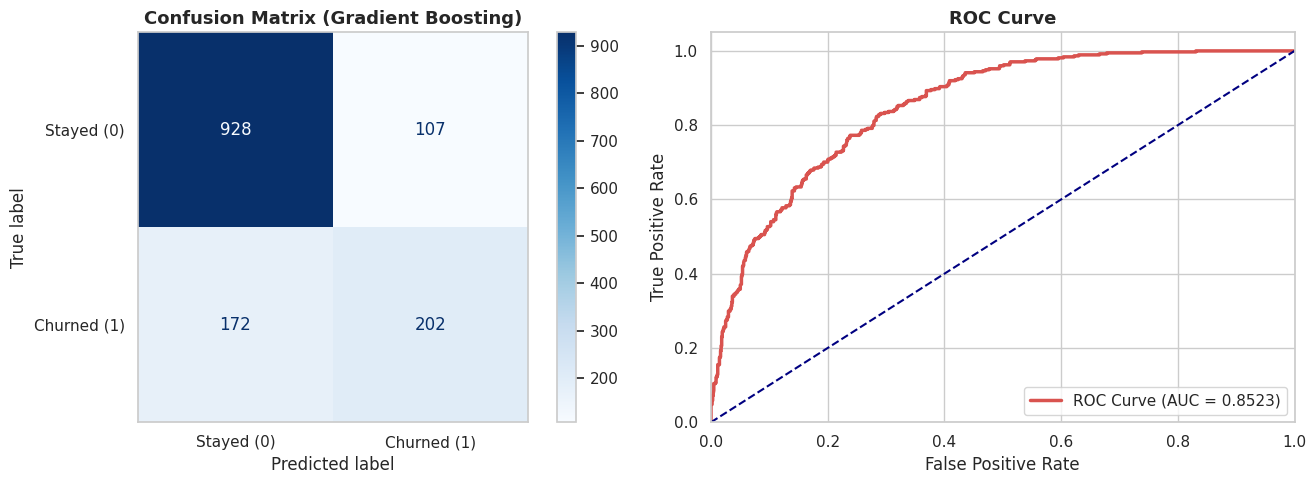

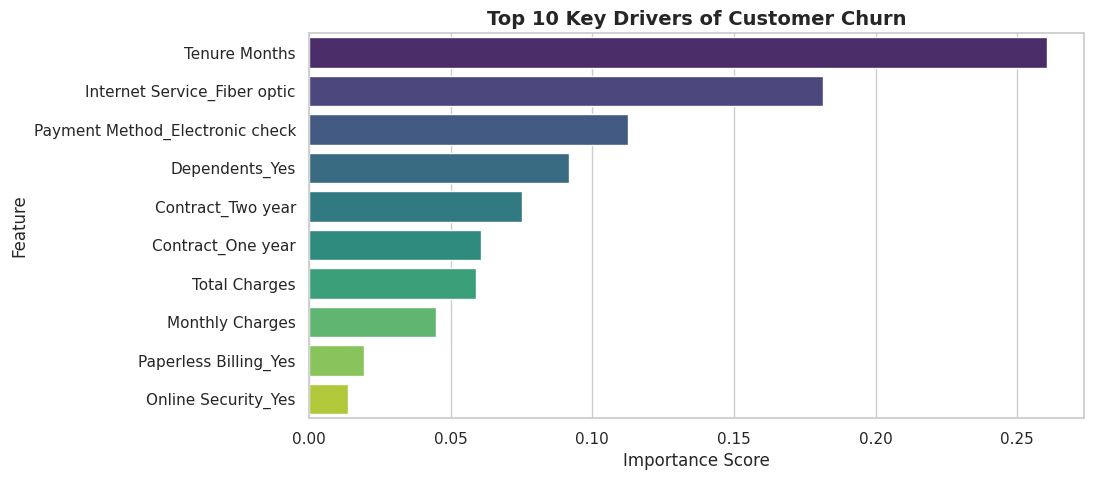

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# 1. Best model ko select karna (Gradient Boosting)
best_model = models["Gradient Boosting"]
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

# 2. Subplots create karna
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (A) Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed (0)', 'Churned (1)'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix (Gradient Boosting)', fontsize=13, fontweight='bold')
axes[0].grid(False)

# (B) ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best)
roc_auc_val = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#d9534f', lw=2.5, label=f'ROC Curve (AUC = {roc_auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# 3. Top 10 Most Important Features (Feature Importance)
feature_importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
top_features = feature_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis', hue=top_features.index, legend=False)
plt.title('Top 10 Key Drivers of Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

In [ ]:
# 1. Scale full dataset features using already fitted scaler
X_full_scaled = X_encoded.copy()
X_full_scaled[num_cols] = scaler.transform(X_encoded[num_cols])

# 2. Predict churn probability for all 7043 customers
df['Churn Probability'] = best_model.predict_proba(X_full_scaled)[:, 1]
df['Churn Probability (%)'] = (df['Churn Probability'] * 100).round(2)

# 3. Create Risk Segments based on probability
def assign_risk(prob):
    if prob < 0.30:
        return 'Low Risk'
    elif prob <= 0.60:
        return 'Medium Risk'
    else:
        return 'High Risk'

df['Churn Risk Segment'] = df['Churn Probability'].apply(assign_risk)

# 4. View Risk Segment Summary
print("--- Churn Risk Segment Breakdown ---")
risk_summary = df['Churn Risk Segment'].value_counts()
print(risk_summary)
print("\nPercentage Distribution:")
print((df['Churn Risk Segment'].value_counts(normalize=True) * 100).round(2))

# 5. Export processed data to CSV for Power BI & SQL
output_filename = 'telco_churn_final_processed.csv'
df.to_csv(output_filename, index=False)
print(f"\n Successfully exported processed dataset to: {output_filename}")

# Download directly to your local computer
from google.colab import files
files.download(output_filename)

--- Churn Risk Segment Breakdown ---
Churn Risk Segment
Low Risk       4395
Medium Risk    1595
High Risk      1053
Name: count, dtype: int64

Percentage Distribution:
Churn Risk Segment
Low Risk       62.40
Medium Risk    22.65
High Risk      14.95
Name: proportion, dtype: float64

 Successfully exported processed dataset to: telco_churn_final_processed.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

--- Churn Rate by Customer Segment ---


,Segment Name,Total Customers,Churn Rate (%)
0,Budget/Low-Usage,2218,44.68
1,Long-term High-Value,1941,15.15
2,Moderate-Tenure Regular,1804,29.10
3,New/Low-Tenure High-Charge,1080,5.46


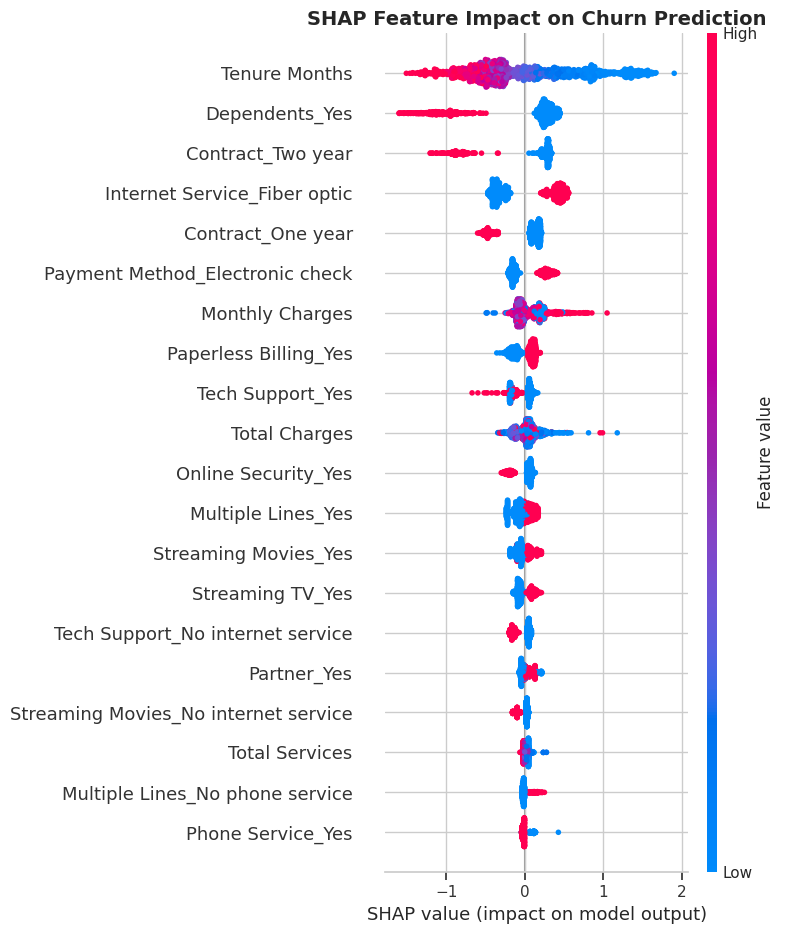

Updated 'telco_churn_final_processed.csv' with Segments & SHAP data.


In [ ]:
# 1. Install and Import SHAP for Model Explainability
!pip install shap -q
import shap
from sklearn.cluster import KMeans

# 2. Customer Segmentation using K-Means Clustering
cluster_features = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Total Services']
X_cluster = df[cluster_features].copy()

# Standardize features for clustering
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Fit KMeans (4 Segments)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Customer_Segment'] = kmeans.fit_predict(X_cluster_scaled)

# Map segment names based on business traits
segment_names = {
    0: 'Long-term High-Value',
    1: 'New/Low-Tenure High-Charge',
    2: 'Budget/Low-Usage',
    3: 'Moderate-Tenure Regular'
}
df['Segment_Name'] = df['Customer_Segment'].map(segment_names)

print("--- Churn Rate by Customer Segment ---")
segment_churn = df.groupby('Segment_Name')['Churn Value'].agg(['count', 'mean']).reset_index()
segment_churn['mean'] = (segment_churn['mean'] * 100).round(2)
segment_churn.columns = ['Segment Name', 'Total Customers', 'Churn Rate (%)']
display(segment_churn)

# 3. SHAP Model Explainability
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=X_train.columns, show=False)
plt.title('SHAP Feature Impact on Churn Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Final CSV update with Segments
df.to_csv('telco_churn_final_processed.csv', index=False)
print("Updated 'telco_churn_final_processed.csv' with Segments & SHAP data.")

In [ ]:
import sqlite3

# 1. SQLite database create karna aur dataframe load karna
conn = sqlite3.connect('telco_churn.db')
df.to_sql('telco_churn', conn, if_exists='replace', index=False)

# 2. Helper function query run karke clean table dekhne ke liye
def run_sql(query):
    return pd.read_sql_query(query, conn)

# --- Query 1: Overall Churn Breakdown ---
q1 = """
SELECT
    [Churn Label],
    COUNT(*) AS Total_Customers,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM telco_churn), 2) AS Churn_Percentage
FROM telco_churn
GROUP BY [Churn Label];
"""
print("--- Query 1: Overall Churn Rate ---")
display(run_sql(q1))

# --- Query 2: Churn by Contract Type ---
q2 = """
SELECT
    Contract,
    COUNT(*) AS Total_Customers,
    SUM([Churn Value]) AS Churned_Customers,
    ROUND(AVG([Churn Value]) * 100, 2) AS Churn_Rate_Pct,
    ROUND(AVG([Monthly Charges]), 2) AS Avg_Monthly_Charges
FROM telco_churn
GROUP BY Contract
ORDER BY Churn_Rate_Pct DESC;
"""
print("\n--- Query 2: Churn Rate by Contract ---")
display(run_sql(q2))

# --- Query 3: Top 10 High-Risk Customers ---
q3 = """
SELECT
    [CustomerID],
    [Tenure Months],
    [Monthly Charges],
    [Payment Method],
    [Churn Risk Segment],
    [Churn Probability (%)]
FROM telco_churn
WHERE [Churn Risk Segment] = 'High Risk'
ORDER BY [Churn Probability (%)] DESC
LIMIT 10;
"""
print("\n--- Query 3: Top 10 High-Risk Customers ---")
display(run_sql(q3))

--- Query 1: Overall Churn Rate ---


,Churn Label,Total_Customers,Churn_Percentage
0,No,5174,73.46
1,Yes,1869,26.54



--- Query 2: Churn Rate by Contract ---


,Contract,Total_Customers,Churned_Customers,Churn_Rate_Pct,Avg_Monthly_Charges
0,Month-to-month,3875,1655,42.71,66.40
1,One year,1473,166,11.27,65.05
2,Two year,1695,48,2.83,60.77



--- Query 3: Top 10 High-Risk Customers ---


,CustomerID,Tenure Months,Monthly Charges,Payment Method,Churn Risk Segment,Churn Probability (%)
0,7216-EWTRS,1,100.80,Electronic check,High Risk,94.71
1,0107-YHINA,1,99.75,Electronic check,High Risk,93.85
2,5419-JPRRN,1,101.45,Electronic check,High Risk,93.85
3,7181-BQYBV,1,102.45,Electronic check,High Risk,92.36
4,3178-FESZO,1,100.25,Credit card (automatic),High Risk,92.12
5,1455-UGQVH,10,98.50,Electronic check,High Risk,92.07
6,0897-FEGMU,11,99.50,Electronic check,High Risk,91.90
7,2012-NWRPA,11,99.55,Electronic check,High Risk,91.90
8,9300-AGZNL,1,94.00,Electronic check,High Risk,91.74
9,9124-LHCJQ,1,85.45,Mailed check,High Risk,91.55


In [ ]:
from google.colab import files
files.download('telco_churn_final_processed.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>